# 드라이브 연결

In [2]:
from google.colab import drive

drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#이미지 zip파일 압축 풀기

In [4]:
import zipfile

# IoT 폴더 내에 zip파일 업로드, IoT 폴더에 video 폴더 생성
zip_file=zipfile.ZipFile("/content/drive/MyDrive/iot2/video.zip")
zip_file.extractall(path="/content/drive/MyDrive/iot2/video")

#라이브러리 불러오기

In [5]:
import os
import random
import fnmatch
import pickle

# data processing
import numpy as np
np.set_printoptions(formatter={'float_kind':lambda x: "%.4f" % x})

import pandas as pd
pd.set_option('display.width', 300)
pd.set_option('display.float_format', '{:,.4f}'.format)
pd.set_option('display.max_colwidth', 200)

# pytorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset

print( f'np.__version__: {np.__version__}' )
print( f'pytorch.__version__: {torch.__version__}' )

# sklearn
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split

# imaging
import cv2
from imgaug import augmenters as img_aug
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
%matplotlib inline
from PIL import Image

#GPU 설정
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

np.__version__: 1.25.2
pytorch.__version__: 2.3.0+cu121
cuda:0


image_path: /content/drive/MyDrive/iot2/video/untitled folder/train_02333_045.png
steering_Angle: 45


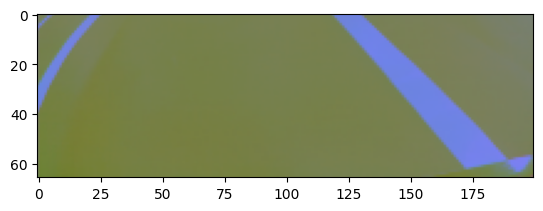

In [9]:
data_dir = '/content/drive/MyDrive/iot2/video/untitled folder'
file_list = os.listdir(data_dir)
image_paths = []
steering_angles = []
pattern = "*.png"
for filename in file_list:
    if fnmatch.fnmatch(filename, pattern):
        image_paths.append(os.path.join(data_dir,filename))
        angle = int(filename[-7:-4])
        steering_angles.append(angle)

image_index = 1
plt.imshow(Image.open(image_paths[image_index]))
print("image_path: %s" % image_paths[image_index] )
print("steering_Angle: %d" % steering_angles[image_index] )
df = pd.DataFrame()
df['ImagePath'] = image_paths
df['Angle'] = steering_angles

(array([710.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 1968.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        1414.0000]),
 array([45.0000, 48.6000, 52.2000, 55.8000, 59.4000, 63.0000, 66.6000,
        70.2000, 73.8000, 77.4000, 81.0000, 84.6000, 88.2000, 91.8000,
        95.4000, 99.0000, 102.6000, 106.2000, 109.8000, 113.4000, 117.0000,
        120.6000, 124.2000, 127.8000, 131.4000, 135.0000]),
 <BarContainer object of 25 artists>)

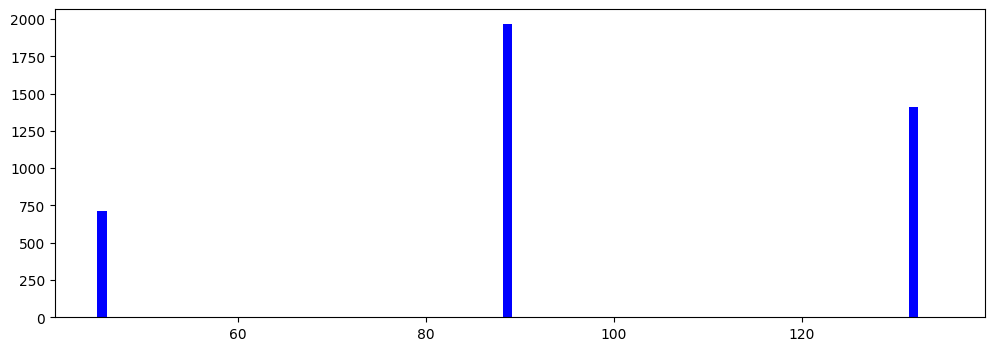

In [10]:
num_of_bins = 25
hist, bins = np.histogram(df['Angle'], num_of_bins)

fig, axes = plt.subplots(1,1, figsize=(12,4))
axes.hist(df['Angle'], bins=num_of_bins, width=1, color='blue')

Training data: 2618
Validation data: 819
Test data: 655


Text(0.5, 1.0, 'Validation Data')

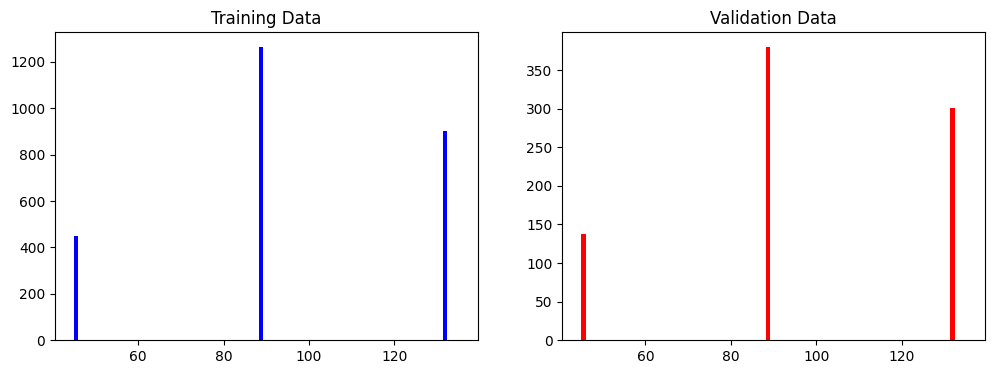

In [11]:
# 5. 학습, 검증, 테스트 데이터 분리

X_train, X_valid, y_train, y_valid = train_test_split( image_paths,steering_angles, test_size=0.2)
X_train, X_test, y_train, y_test = train_test_split(X_train, y_train, test_size=0.2)
print("Training data: %d\nValidation data: %d\nTest data: %d" % (len(X_train), len(X_valid), len(X_test)))

fig, axes = plt.subplots(1,2, figsize=(12,4))
axes[0].hist(y_train, bins=num_of_bins, width=1, color='blue')
axes[0].set_title('Training Data')
axes[1].hist(y_valid, bins=num_of_bins, width=1, color='red')
axes[1].set_title('Validation Data')

In [15]:
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
        )
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 5 * 13, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 1)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

# 모델 초기화
model = CNNModel()

# 옵티마이저 및 손실 함수 설정
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

# 출력, 테스트
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params}")

Total parameters: 9040193


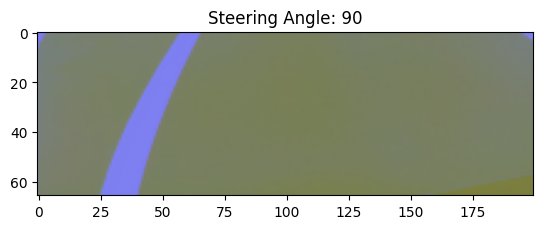

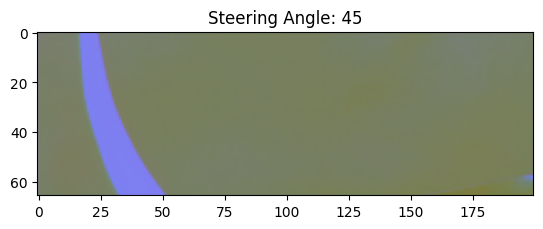

In [16]:
# Define transformations for image preprocessing
transformations = transforms.Compose([
    transforms.Resize((66, 200)),
    transforms.ToTensor()
])

class CustomImageDataset(Dataset):
    def __init__(self, image_paths, steering_angles, transform=None):
        self.image_paths = image_paths
        self.steering_angles = steering_angles
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        steering_angle = self.steering_angles[idx]

        image = Image.open(image_path)
        #image = image.convert('RGB')  # RGB로 변환

        if self.transform:
            image = self.transform(image)

        return image, steering_angle

# 데이터 생성
train_dataset = CustomImageDataset(X_train, y_train, transform=transformations)
valid_dataset = CustomImageDataset(X_valid, y_valid, transform=transformations)
test_dataset = CustomImageDataset(X_test, y_test, transform=transformations)
train_loader = DataLoader(train_dataset, batch_size=100, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=100, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=100, shuffle=True)

images, steering_angles = next(iter(test_loader))
for i in range(2):
    plt.imshow(images[i].permute(1, 2, 0))
    plt.title(f"Steering Angle: {steering_angles[i]}")
    #plt.axis('off')
    plt.show()


In [17]:
# Training loop
model_output_dir = "/content/drive/MyDrive/iot2/output"
best_loss = float('inf')
history = {'train_loss': [], 'val_loss': []}
for epoch in range(10):
    model.train()
    train_losses = []
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels.unsqueeze(1).float())  # Unsqueeze labels for proper shape
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())
    train_loss = np.mean(train_losses)

    model.eval()
    valid_losses = []
    with torch.no_grad():
        for images, labels in valid_loader:
            outputs = model(images)
            loss = criterion(outputs, labels.unsqueeze(1).float())  # Unsqueeze labels for proper shape
            valid_losses.append(loss.item())
    valid_loss = np.mean(valid_losses)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(valid_loss)

    print(f"Epoch {epoch+1}, Train Loss: {train_loss:.4f}, Validation Loss: {valid_loss:.4f}")

    # Save checkpoint if validation loss improves
    if valid_loss < best_loss:
        best_loss = valid_loss
        torch.save(model.state_dict(), os.path.join(model_output_dir, 'lane_navigation_check_F.pth'))
        print("Saved Best Model")

# Save final model
torch.save(model.state_dict(), os.path.join(model_output_dir, 'lane_navigation_final_F.pth'))

# Save training history
history_path = os.path.join(model_output_dir, 'history.pickle')
with open(history_path, 'wb') as f:
    pickle.dump(history, f)



Epoch 1, Train Loss: 3215.3606, Validation Loss: 1084.9086
Saved Best Model
Epoch 2, Train Loss: 1072.4970, Validation Loss: 1045.8977
Saved Best Model
Epoch 3, Train Loss: 1027.0868, Validation Loss: 1107.7046
Epoch 4, Train Loss: 988.3782, Validation Loss: 973.0380
Saved Best Model
Epoch 5, Train Loss: 1002.3706, Validation Loss: 964.9851
Saved Best Model
Epoch 6, Train Loss: 1014.5922, Validation Loss: 943.4593
Saved Best Model
Epoch 7, Train Loss: 958.3719, Validation Loss: 982.4699
Epoch 8, Train Loss: 957.4009, Validation Loss: 1021.8364
Epoch 9, Train Loss: 929.6838, Validation Loss: 884.0584
Saved Best Model
Epoch 10, Train Loss: 876.3617, Validation Loss: 812.2038
Saved Best Model


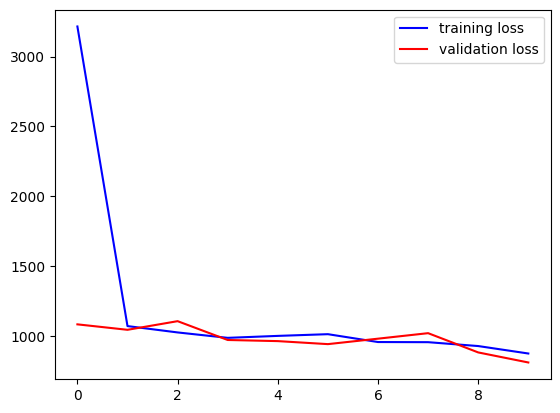

In [18]:
history_path = os.path.join(model_output_dir,'history.pickle')
with open(history_path, 'rb') as f:
    history = pickle.load(f)

history
plt.plot(history['train_loss'],color='blue')
plt.plot(history['val_loss'],color='red')
plt.legend(["training loss", "validation loss"])

In [19]:
from sklearn.metrics import mean_squared_error, r2_score

def summarize_prediction(Y_true, Y_pred):

    mse = mean_squared_error(Y_true, Y_pred)
    r_squared = r2_score(Y_true, Y_pred)

    print(f'mse       = {mse:.2}')
    print(f'r_squared = {r_squared:.2%}')
    print()

def predict_and_summarize(X, Y, model):
    model.load_state_dict(torch.load(f'{model_output_dir}/lane_navigation_final_F.pth'))
    model.eval()
    Y_pred = []
    with torch.no_grad():
        for i, data in enumerate(test_loader):
            inputs, labels = data

            outputs = model(inputs)
            prediction = outputs.max(1, keepdim = True)[1]
            Y_pred.extend(outputs)


    Y_pred = torch.tensor(Y_pred)
    summarize_prediction(Y, Y_pred)
    return Y_pred

y_pred = predict_and_summarize(X_test, y_test, model)



mse       = 1.1e+03
r_squared = -14.20%



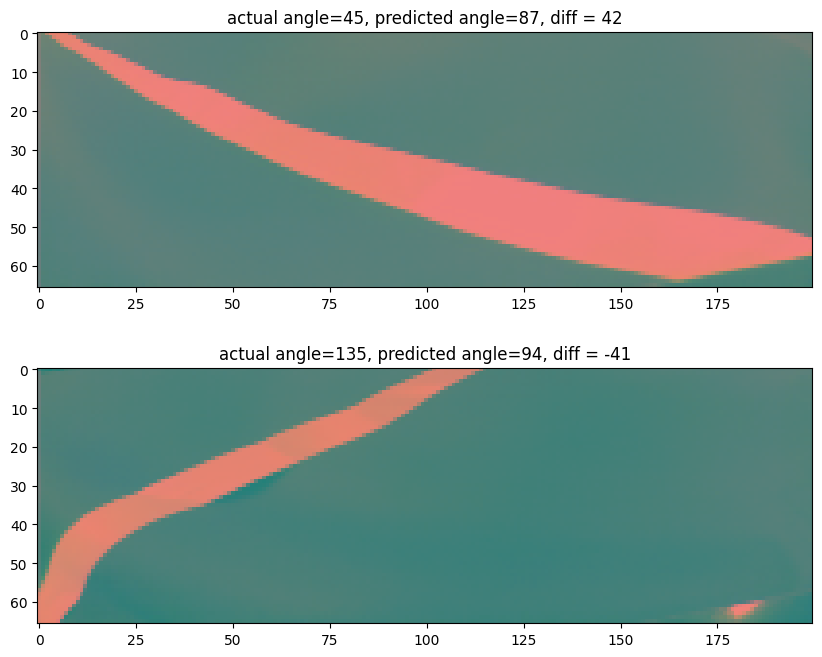

In [20]:
n_tests_show = 2
fig, axes = plt.subplots(n_tests_show, 1, figsize=(10, 4 * n_tests_show))
for i in range(n_tests_show):
    image = cv2.imread(X_valid[i])
    axes[i].imshow(image)
    axes[i].set_title(f"actual angle={y_valid[i]}, predicted angle={int(y_pred[i])}, diff = {int(y_pred[i])-y_valid[i]}")